<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10300 non-null  object 
 1   email                    10300 non-null  object 
 2   first_name               10300 non-null  object 
 3   last_name                10300 non-null  object 
 4   age                      9071 non-null   float64
 5   gender                   9476 non-null   object 
 6   country                  10300 non-null  object 
 7   state_province           10300 non-null  object 
 8   city                     10300 non-null  object 
 9   subscription_plan        10300 non-null  object 
 10  subscription_start_date  10300 non-null  object 
 11  is_active                10300 non-null  bool   
 12  monthly_spend            9283 non-null   float64
 13  primary_device           10300 non-null  object 
 14  household_size        

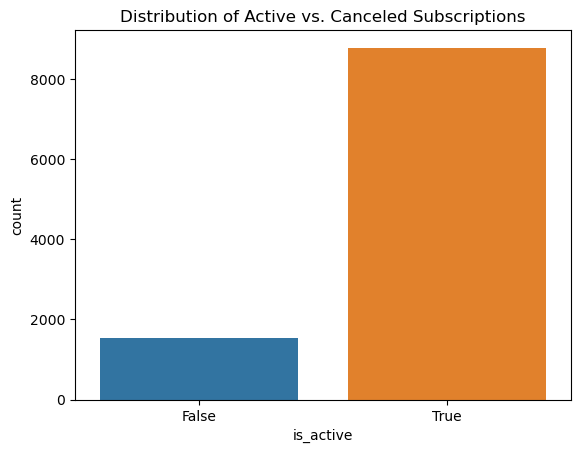

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("users.csv")

#Find the number of columns and names and which ones have null values
print(df.info())

#Visually understand how distributed is the is_active variable
sns.countplot(data=df, x='is_active')
plt.title('Distribution of Active vs. Canceled Subscriptions')

#Exploring the data
# 1) Average monthly spend
avg_spend = df['monthly_spend'].mean()
print(f"Average monthly spend: ${avg_spend:.2f}")

# 2) Most common (modal) subscription plan
most_common_plan = df['subscription_plan'].mode().iat[0]
print(f"Most common plan: {most_common_plan}")


In [6]:
#Summary of each column with count of Null values
print(df.isnull().sum())

user_id                       0
email                         0
first_name                    0
last_name                     0
age                        1229
gender                      824
country                       0
state_province                0
city                          0
subscription_plan             0
subscription_start_date       0
is_active                     0
monthly_spend              1017
primary_device                0
household_size             1545
created_at                    0
dtype: int64


In [7]:
#For simplicity, eliminate the null values and print the summary
df = df.dropna()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6379 entries, 0 to 10299
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  6379 non-null   object 
 1   email                    6379 non-null   object 
 2   first_name               6379 non-null   object 
 3   last_name                6379 non-null   object 
 4   age                      6379 non-null   float64
 5   gender                   6379 non-null   object 
 6   country                  6379 non-null   object 
 7   state_province           6379 non-null   object 
 8   city                     6379 non-null   object 
 9   subscription_plan        6379 non-null   object 
 10  subscription_start_date  6379 non-null   object 
 11  is_active                6379 non-null   bool   
 12  monthly_spend            6379 non-null   float64
 13  primary_device           6379 non-null   object 
 14  household_size           637

In [14]:
#Start building the model by getting the variables ready

#Selection of the X variables based on logic Business Experience
features = ['age','gender','country','subscription_plan','monthly_spend','household_size','primary_device']
target = 'is_active'

#Create a sub dataframe with the variables for the model
df_model = df[features + [target]].copy()

#Convert the target values of "is_active" into 1 or 0 because they are in True / False
# is_active = 1 means that the subscription is active
# is_active = 0 means that the subscription is no longer active
df_model['is_active'] = df_model['is_active'].astype(int)

#Now we need to create dummies for those columns that have string categorical data
df_model = pd.get_dummies(df_model, columns=['gender','country','subscription_plan','primary_device'], drop_first=True)
df_model.head()

,age,monthly_spend,household_size,is_active,gender_Male,gender_Other,gender_Prefer not to say,country_USA,subscription_plan_Premium,subscription_plan_Premium+,subscription_plan_Standard,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet
0,43.0,36.06,1.0,1,True,False,False,True,False,False,False,False,True,False,False,False
1,38.0,14.59,2.0,1,True,False,False,True,False,True,False,False,False,False,False,False
2,32.0,11.71,3.0,0,False,False,False,True,False,False,True,False,False,False,False,False
3,11.0,28.56,2.0,1,True,False,False,True,False,False,True,False,True,False,False,False
4,21.0,9.54,6.0,1,False,False,False,True,False,False,True,False,False,False,False,False


Accuracy: 0.47335423197492166
Classification Report:
               precision    recall  f1-score   support

           0      0.141     0.545     0.225       268
           1      0.862     0.462     0.601      1646

    accuracy                          0.473      1914
   macro avg      0.502     0.503     0.413      1914
weighted avg      0.761     0.473     0.549      1914

Confusion Matrix:
 [[146 122]
 [886 760]]


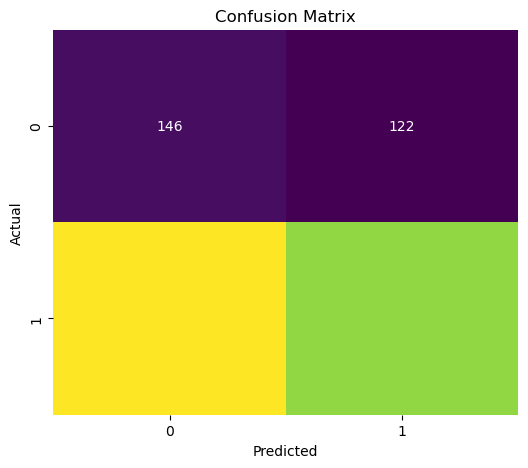

In [37]:
#Building the model
X = df_model.drop('is_active',axis=1)
Y = df_model['is_active']

#Split the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

#Train the model
model = LogisticRegression(max_iter=1000,class_weight='balanced').fit(X_train,y_train)

#Predictions
Y_pred = model.predict(X_test)
Y_pred_prob = model.predict_proba(X_test)[:,1]

#Metrics
acc = accuracy_score(y_test,Y_pred)
cm = confusion_matrix(y_test,Y_pred)
cr = classification_report(y_test, Y_pred,digits=3)
labels = ['Cancelled (0)', 'Active (1)']

print('Accuracy:',acc)
print('Classification Report:\n',cr)

print("Confusion Matrix:\n", cm)

#Confussion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
#Coefficient of determination for each variable

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

# Order by DESC
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

                         Variable  Coefficient
11          primary_device_Laptop     0.273624
13        primary_device_Smart TV     0.050245
3                     gender_Male     0.024790
8      subscription_plan_Premium+     0.009251
0                             age     0.006747
1                   monthly_spend     0.000405
2                  household_size    -0.005211
6                     country_USA    -0.005964
10  primary_device_Gaming Console    -0.036290
14          primary_device_Tablet    -0.036838
4                    gender_Other    -0.052651
5        gender_Prefer not to say    -0.086782
12          primary_device_Mobile    -0.137167
9      subscription_plan_Standard    -0.144913
7       subscription_plan_Premium    -0.157440
